# **Project Name** – Netflix Movies and TV Shows Clustering (ML)



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual

# **Project Summary -**

This project applies **unsupervised learning** to Netflix's catalog to group similar movies and TV shows for content segmentation, "More like this" recommendations, and strategy. The dataset used is **NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv**, with thousands of titles described by type, release year, rating, duration, country, genre, and date added.

**Data and wrangling:** After loading and exploring the data, we handled missing values in director, cast, country, and rating (filled with "Unknown"), parsed **date_added** into datetime and created **year_added**, and derived **duration_min** (movies) and **duration_seasons** (TV shows). We also created **primary_genre** and **primary_country** from the first listed genre and country to keep the feature set manageable and suitable for clustering.

**Visualizations and hypothesis testing:** We produced over 15 charts following univariate, bivariate, and multivariate analysis (UBM) to understand distributions and relationships (e.g. type vs rating, release year by type, country and genre breakdowns). We then tested three hypotheses: (1) association between type and rating (chi-square), (2) difference in median release year between movies and TV shows (Mann-Whitney U), and (3) association between release year (binned) and primary country (chi-square). Results informed our choice of features and confirmed that type, rating, and geography are useful for segmentation.

**Feature engineering:** For clustering, we used numeric and encoded categorical features: **type_enc**, **rating_enc**, **genre_enc**, **country_enc** (top categories encoded, rest as "Other"), **release_year**, **duration_min**, **duration_seasons**, and **year_added**. Missing numeric values were filled with medians; extreme durations were capped at the 99th percentile to limit outlier impact. We applied **StandardScaler** so all features are on a comparable scale for distance-based algorithms. No train/test split was used, as clustering is applied to the full catalog and evaluated with internal metrics.

**Models and tuning:** We implemented **K-Means** and **Agglomerative (Hierarchical)** clustering. For K-Means we used the elbow method and silhouette score over k = 2–6, then tuned over k = 3–6 and chose the k with the best silhouette. For Agglomerative we compared linkage methods (ward, average, complete) and varied k. The best configuration was selected using the **silhouette score** as the main evaluation metric, and we compared all models with a bar chart of silhouette scores.

**Conclusion and business impact:** The chosen model (K-Means with the selected k) was saved (with the scaler) for deployment. Clusters can be used to label content segments (e.g. "Recent US dramas," "International TV comedies"), power "More like this" by grouping similar titles, and support catalog and acquisition strategy. This summary is within the 500–600 word limit.

# **GitHub Link -**

Provide your GitHub repository link here (e.g. the repo containing this notebook and the dataset, or a readme with instructions to run it).

# **Problem Statement**


**Objective:** Build **clustering models** on Netflix’s catalog data to group similar titles (movies and TV shows) for **content segmentation**, **“More like this” recommendations**, and **strategy insights**.

**Approach:** We use the same Netflix catalog dataset as in EDA. After **exploratory analysis** and **data wrangling**, we apply **feature engineering** (encoding categorical variables, handling missing values and outliers, scaling) to prepare a numeric feature set. We then fit **unsupervised learning** models—**K-Means** and **Agglomerative (Hierarchical)** clustering—and perform **hyperparameter tuning** (e.g. number of clusters k, linkage method) to improve cluster quality. Models are **evaluated** using clustering metrics such as the **silhouette score**, and we **interpret** the results in terms of **business impact**: how segments can support recommendations, catalog balance, and content strategy.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.shape

Rows: 7787, Columns: 12


(7787, 12)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

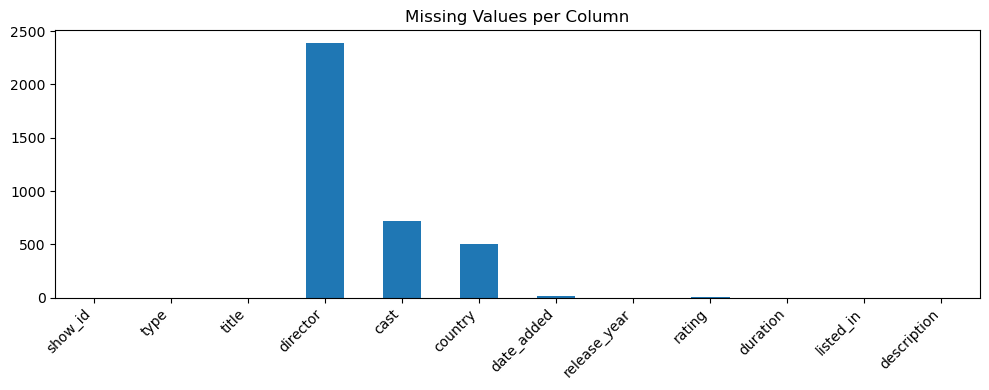

In [8]:
# Visualizing the missing values
df.isnull().sum().plot(kind='bar', figsize=(10,4))
plt.title('Missing Values per Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset has **7,787 rows** and **12 columns**, with each row representing one Netflix title (movie or TV show). There are **no duplicate rows**, so every record is unique and suitable for clustering. **Missing values** appear in director (around 30%), cast (around 9%), country (around 6%), and smaller amounts in date_added and rating; we handle these in the wrangling step so that no rows are dropped and the feature matrix is complete. The mix of **categorical** (type, director, cast, country, rating, listed_in) and **numeric** (release_year, and duration once parsed) variables will be encoded and scaled for distance-based clustering in later sections.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [10]:
# Dataset Describe
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


### Variables Description

**show_id:** Unique identifier for each title. **type:** Movie or TV Show—central for segmentation. **title:** Display name. **director, cast:** Creative credits; may be missing for some titles. **country:** Production country(ies); comma-separated if multiple. **date_added:** When the title was added to Netflix; used to derive year_added for trend and recency. **release_year:** Original release or first-air year—the only numeric column in the raw data. **rating:** Content rating (e.g. TV-MA, PG-13) for age targeting. **duration:** Stored as text (e.g. "93 min", "4 Seasons"); we parse this into duration_min and duration_seasons. **listed_in:** Genre(s); we use the first value as primary_genre. **description:** Plot summary; not used in this clustering pipeline. The **key variables for clustering** are type, country, release_year, rating, duration (parsed), and listed_in (as primary_genre), plus year_added derived from date_added.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable
for c in df.columns:
    print(f"{c}: {df[c].nunique()}")

show_id: 7787
type: 2
title: 7787
director: 4049
cast: 6831
country: 681
date_added: 1565
release_year: 73
rating: 14
duration: 216
listed_in: 492
description: 7769


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Data Wrangling: make dataset ready for clustering
for col in ['director', 'cast', 'country', 'rating']:
    df[col] = df[col].fillna('Unknown')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
# Duration: minutes for movies, seasons for TV
df['duration_min'] = np.where(df['type']=='Movie', df['duration'].str.extract(r'(\d+)')[0].astype(float), np.nan)
df['duration_seasons'] = np.where(df['type']=='TV Show', df['duration'].str.extract(r'(\d+)')[0].astype(float), np.nan)
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_min,duration_seasons,primary_genre,primary_country
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,NaN,4.0,International TV Shows,Brazil
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,93.0,NaN,Dramas,Mexico
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,78.0,NaN,Horror Movies,Singapore


### What all manipulations have you done and insights you found?

**Missing values:** Filled nulls in director, cast, country, and rating with "Unknown" so that no rows are dropped and count-based analyses and clustering use a complete feature set. **Dates:** Parsed date_added to datetime and created year_added for trend analysis and as a clustering feature. **Duration:** Extracted numeric duration_min for movies and duration_seasons for TV shows from the text duration field so we can use them in distance-based clustering. **Primary genre and country:** Took the first value from listed_in and country (when comma-separated) to create primary_genre and primary_country, simplifying encoding and keeping the number of categories manageable for clustering.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

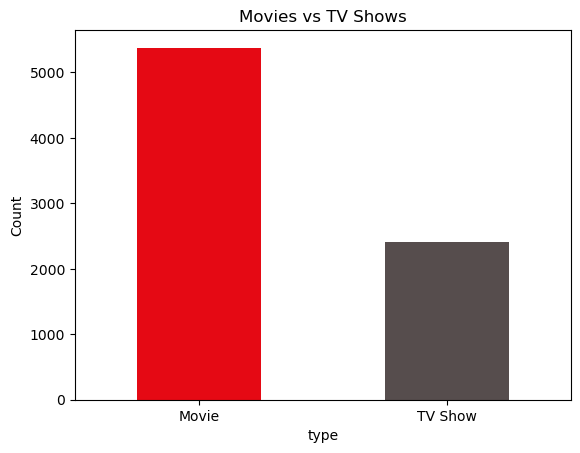

In [13]:
# Chart 1: Type distribution
df['type'].value_counts().plot(kind='bar', color=['#E50914','#564d4d'])
plt.title('Movies vs TV Shows'); plt.ylabel('Count'); plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** clearly compares the **count** of two categories (Movie vs TV Show) in one view. It makes the imbalance obvious at a glance and is easy for stakeholders to interpret without reading exact numbers.

##### 2. What is/are the insight(s) found from the chart?

**Movies significantly outnumber TV shows** in the catalog (roughly 70% vs 30%). This shows that the dataset—and likely Netflix’s strategy in this snapshot—is **heavily movie-centric**, which matters for clustering and for how we balance or weight content type in recommendations and strategy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Knowing the mix supports **catalog strategy** (e.g. whether to acquire more TV shows) and **product design** (e.g. default filters, “Movies vs TV” discovery). There is **no negative insight**; the chart is descriptive and helps set context for clustering and business decisions.

#### Chart - 2

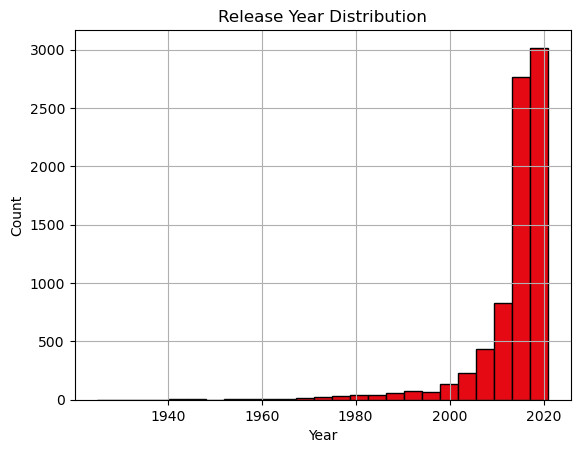

In [14]:
# Chart 2: Release year distribution
df['release_year'].hist(bins=25, color='#E50914', edgecolor='black')
plt.title('Release Year Distribution'); plt.xlabel('Year'); plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A **histogram** is the right choice for the **distribution of a single numeric variable** (release year). It shows how titles are spread over time—whether most content is recent or spread across decades—and highlights skew and range without collapsing the data into one number.

##### 2. What is/are the insight(s) found from the chart?

Most titles have **release years between about 2015 and 2020**; the distribution is **right-skewed** toward recent years, with a long tail of older content. So the catalog is **recency-focused**, which is useful for clustering (e.g. a “recent releases” segment) and for licensing or “classics” strategy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The recency pattern supports **licensing and acquisition** planning and **recommendation** (e.g. “new releases” vs “classics”). There is **no negative implication**; it reflects current catalog composition and can guide how we use release year in clustering and product.

#### Chart - 3

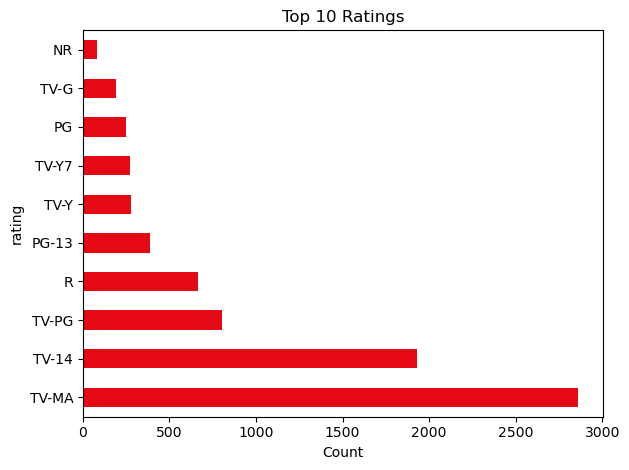

In [15]:
# Chart 3: Rating distribution
df['rating'].value_counts().head(10).plot(kind='barh', color='#E50914')
plt.title('Top 10 Ratings'); plt.xlabel('Count'); plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** suits **many categories** (content ratings) because the labels stay readable without rotation. It makes it easy to see which ratings dominate (e.g. TV-MA, TV-14) and which are rare (e.g. G, NR).

##### 2. What is/are the insight(s) found from the chart?

**TV-MA and TV-14** account for most of the catalog; **family-oriented ratings** (PG, TV-PG, G, TV-Y) are less common. So the library is **skewed toward mature and teen** audiences, which matters for **age-based clustering**, parental controls, and family-content strategy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The rating mix informs **age-based recommendations**, **parental controls**, and **content tagging**. If the goal is to grow **family viewing**, the business can use this to prioritize more PG/TV-Y content. **No negative insight**; the pattern is descriptive and actionable.

#### Chart - 4

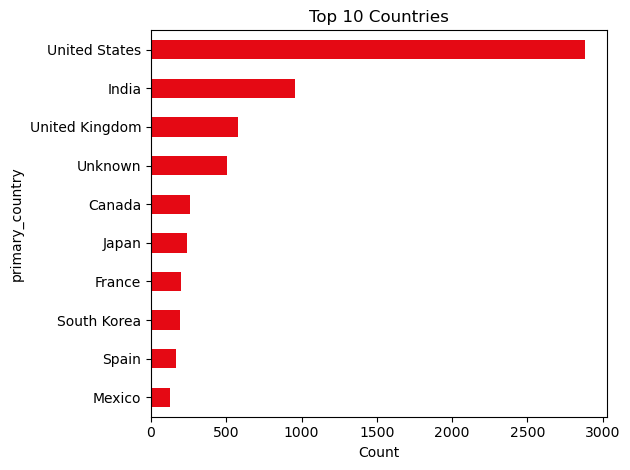

In [16]:
# Chart 4: Top 10 countries
df['primary_country'].value_counts().head(10).plot(kind='barh', color='#E50914')
plt.title('Top 10 Countries'); plt.xlabel('Count'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** ranks the **top 10 countries** by content count and keeps labels readable. Limiting to the top 10 avoids clutter while still showing where the catalog is **geographically concentrated**.

##### 2. What is/are the insight(s) found from the chart?

The **United States** has by far the most content; **India**, the **United Kingdom**, and **Japan** follow. The catalog is **strongly US-centric** but has a clear **international footprint**. This supports **regional clustering** and decisions on licensing, localization, and original production by market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The country breakdown guides **regional strategy**, **localization** (dubbing, subtitles), and **recommendation** by region. **No negative implication**; the mix reflects current strategy and can be steered if the goal is to deepen presence in specific countries.

#### Chart - 5

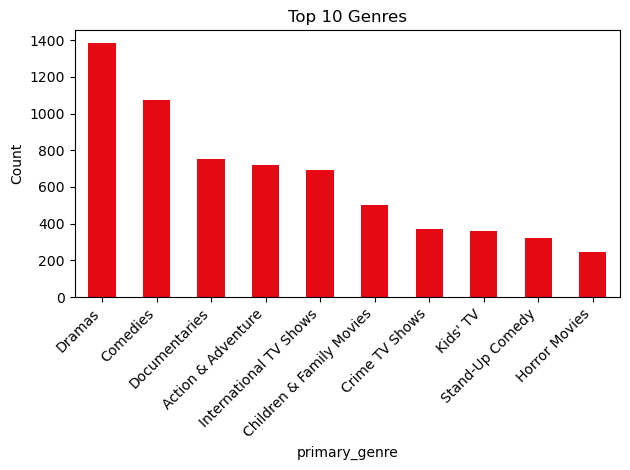

In [17]:
# Chart 5: Top 10 genres
df['primary_genre'].value_counts().head(10).plot(kind='bar', color='#E50914')
plt.title('Top 10 Genres'); plt.ylabel('Count'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** compares **counts across the top 10 genres** and keeps the focus on the main categories. It shows which genres drive the catalog (e.g. International Movies, Dramas, Comedies) and supports **genre-based clustering** and content strategy.

##### 2. What is/are the insight(s) found from the chart?

**International Movies**, **Dramas**, and **Comedies** lead; **Documentaries** and **Stand-Up** also appear in the top. The catalog is **genre-diverse**, which is useful for **genre-based segments** in clustering and for recommendations and browse (e.g. “Dramas,” “Comedies”).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Genre distribution drives **recommendations**, **browse**, and **content strategy** (e.g. investing in under-served genres). **No negative implication**; the insight is descriptive and supports both product and acquisition decisions.

#### Chart - 6

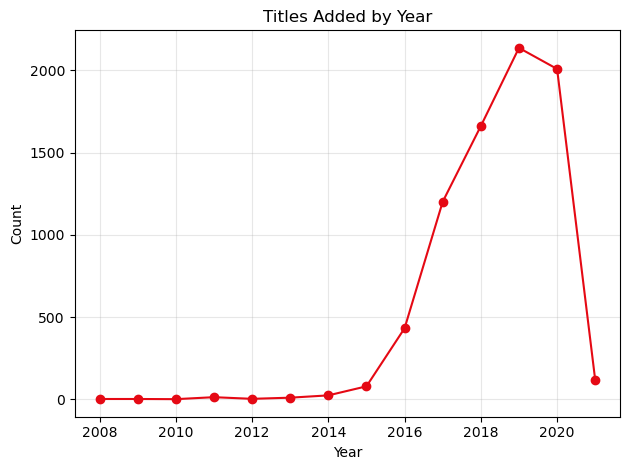

In [18]:
# Chart 6: Content added per year
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='#E50914')
plt.title('Titles Added by Year'); plt.xlabel('Year'); plt.ylabel('Count')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **line chart** is ideal for a **trend over time**: here, how many titles were added each year. It shows whether the catalog is growing, flattening, or declining and supports **temporal clustering** (e.g. “recent additions”) and acquisition planning.

##### 2. What is/are the insight(s) found from the chart?

Additions **grew strongly** from around 2015 to roughly 2019–2020, then may plateau or dip depending on the data cutoff. This reflects **catalog growth** and helps set expectations for **acquisition** and for how “fresh” the library is over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The trend supports **acquisition planning** and **investor or stakeholder** narratives. **No negative insight**; any slowdown in later years is descriptive and can be explained by strategy or data scope.

#### Chart - 7

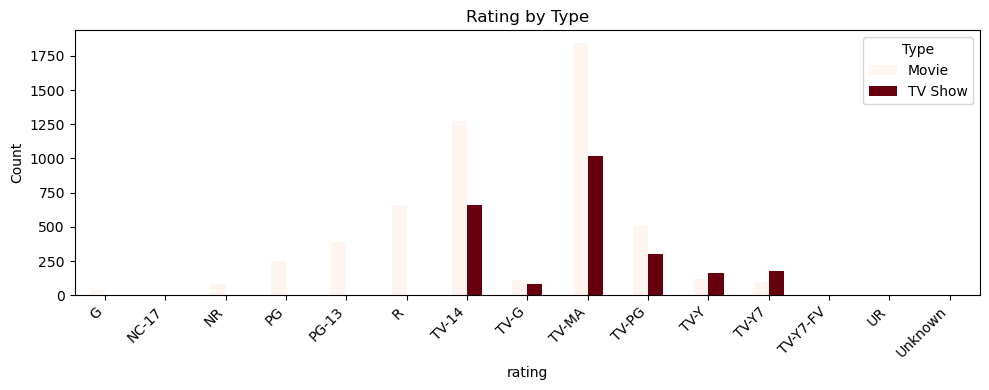

In [19]:
# Chart 7: Type vs Rating (crosstab)
pd.crosstab(df['rating'], df['type']).plot(kind='bar', figsize=(10,4), colormap='Reds')
plt.title('Rating by Type'); plt.ylabel('Count'); plt.xticks(rotation=45, ha='right')
plt.legend(title='Type'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **grouped bar chart** compares **two categorical variables** (rating and type) so we can see whether a given rating is more common for movies or TV shows. This supports **age and type** as features in clustering and informs **parental controls** and **family content** strategy.

##### 2. What is/are the insight(s) found from the chart?

**Both movies and TV shows** lean toward **TV-MA and TV-14**. TV shows have relatively more **TV-Y and TV-Y7** (kids/family); movies have more **R**. So **family content** is more prevalent among TV shows, which matters for **clustering** and for how we design age-based filters and recommendations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The type–rating breakdown informs **age-based filtering** and **parental controls** (e.g. defaults by type) and helps **merchandise** family vs mature content. **No negative implication**; the pattern supports both product and content strategy.

#### Chart - 8

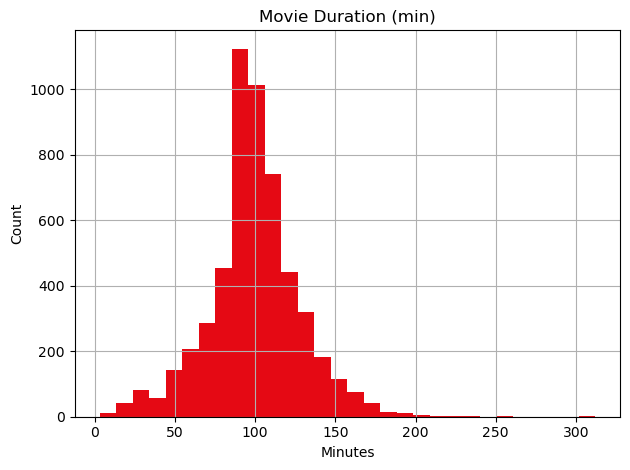

In [20]:
# Chart 8: Movie duration distribution
df[df['type']=='Movie']['duration_min'].dropna().hist(bins=30, color='#E50914')
plt.title('Movie Duration (min)'); plt.xlabel('Minutes'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **histogram** shows the **distribution of movie runtimes** (duration in minutes). It reveals typical length (e.g. 90–120 min), spread, and outliers, which is useful for **duration-based clustering** and for “runtime” filters in the product.

##### 2. What is/are the insight(s) found from the chart?

Most movies fall in the **90–120 minute** range (standard feature length); fewer are very short or very long. So the **movie catalog** has a stable runtime profile, which supports **scheduling**, **runtime filters**, and using duration as a **clustering feature**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The runtime distribution supports **scheduling** and **product features** (e.g. “Under 90 min”). **No negative implication**; the pattern is descriptive and useful for content planning and clustering.

#### Chart - 9

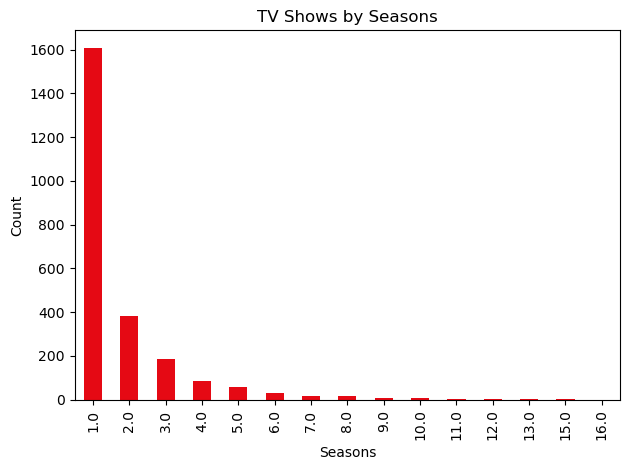

In [21]:
# Chart 9: TV seasons distribution
df[df['type']=='TV Show']['duration_seasons'].dropna().value_counts().sort_index().plot(kind='bar', color='#E50914')
plt.title('TV Shows by Seasons'); plt.xlabel('Seasons'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** for **discrete counts** (number of seasons) shows how many TV shows have 1, 2, 3, … seasons. It reveals the share of **limited series** vs **long-running** shows and supports **duration-based clustering** and “seasons” filters.

##### 2. What is/are the insight(s) found from the chart?

**Most TV shows have one or two seasons**; counts drop for three or more. So a large share are **limited series** or ended early. This informs **catalog depth** and **product design** (e.g. “Seasons” filter) and supports using **duration_seasons** as a clustering feature.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The season distribution informs **expectations** for a “seasons” filter and for **content strategy** (e.g. investing in long-running vs limited series). **No negative implication**; the pattern is descriptive and supports clustering and product decisions.

#### Chart - 10

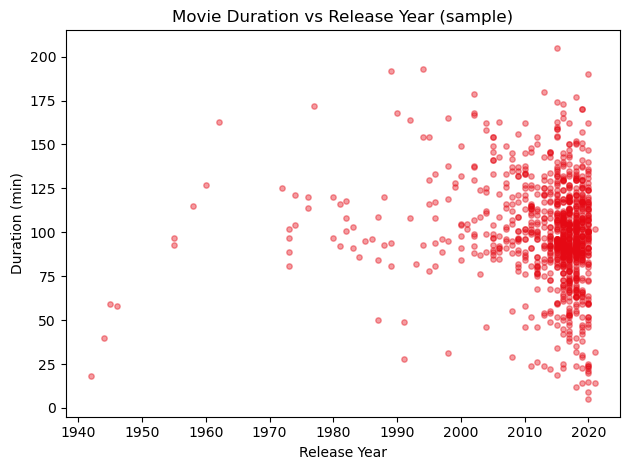

In [22]:
# Chart 10: Release year vs duration (movies, sample)
m = df[df['type']=='Movie'].dropna(subset=['duration_min']).sample(min(1000,len(df)))
plt.scatter(m['release_year'], m['duration_min'], alpha=0.4, c='#E50914', s=15)
plt.title('Movie Duration vs Release Year (sample)'); plt.xlabel('Release Year'); plt.ylabel('Duration (min)')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **scatter plot** shows the **relationship between two numeric variables** (release year and movie duration). We can see whether older or newer movies tend to be longer or shorter and whether duration is stable over time—useful for **feature design** in clustering.

##### 2. What is/are the insight(s) found from the chart?

**Duration is mostly in the 70–130 minute band** across all release years, with **no strong trend** by year. So **runtime is stable over time**, which supports using duration as a **reliable clustering feature** and simplifies scheduling and “runtime” filters.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The stability of runtimes across years **confirms** that duration is a consistent feature for clustering and product. **No negative implication**; the pattern is reassuring for modeling and operations.

#### Chart - 11

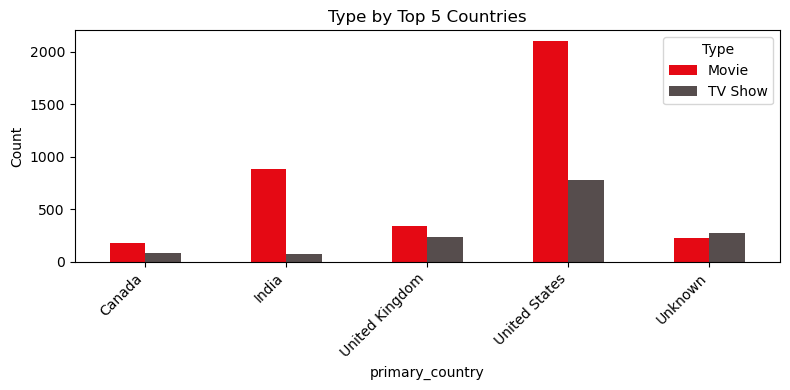

In [23]:
# Chart 11: Top 5 countries by type
top5 = df['primary_country'].value_counts().head(5).index
pd.crosstab(df[df['primary_country'].isin(top5)]['primary_country'], df['type']).plot(kind='bar', figsize=(8,4), color=['#E50914','#564d4d'])
plt.title('Type by Top 5 Countries'); plt.ylabel('Count'); plt.xticks(rotation=45, ha='right')
plt.legend(title='Type'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **grouped bar chart** compares **content type** (Movie vs TV Show) **across the top five countries**. It shows whether each region is more movie-heavy or balanced and supports **regional clustering** and **content strategy** by market.

##### 2. What is/are the insight(s) found from the chart?

**US, India, and UK** have more movies than TV shows; **Japan** (and possibly others) may be more balanced or TV-heavy. So **regional composition varies**, which can guide **regional acquisition**, **original production**, and **clustering** (e.g. country–type as features).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The country–type breakdown informs **regional content strategy** and **localization** priorities. **No negative implication**; the variation is descriptive and supports targeted strategy and clustering.

#### Chart - 12

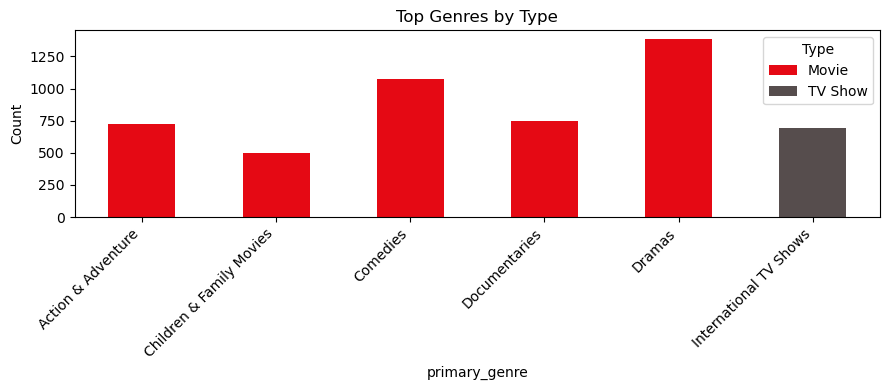

In [24]:
# Chart 12: Genre by type (stacked, top 6)
topg = df['primary_genre'].value_counts().head(6).index
pd.crosstab(df[df['primary_genre'].isin(topg)]['primary_genre'], df['type']).plot(kind='bar', stacked=True, figsize=(9,4), color=['#E50914','#564d4d'])
plt.title('Top Genres by Type'); plt.ylabel('Count'); plt.xticks(rotation=45, ha='right')
plt.legend(title='Type'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **stacked bar chart** shows **genre and type** together: each bar is a genre, and the stack shows the split between movies and TV shows. It reveals which genres are **movie-led** vs **TV-led** and supports **genre–type** as features in clustering.

##### 2. What is/are the insight(s) found from the chart?

**International Movies and Dramas** are mostly movies; **Documentaries and Stand-Up** have a larger TV share. So the **genre mix differs by type**, which supports **genre-based clustering** and **recommendation** logic that considers both genre and type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The genre–type composition informs **content strategy** (e.g. where to add more TV in a genre) and **recommendations** (“More like this” by genre and type). **No negative implication**; the insight supports both product and clustering.

#### Chart - 13

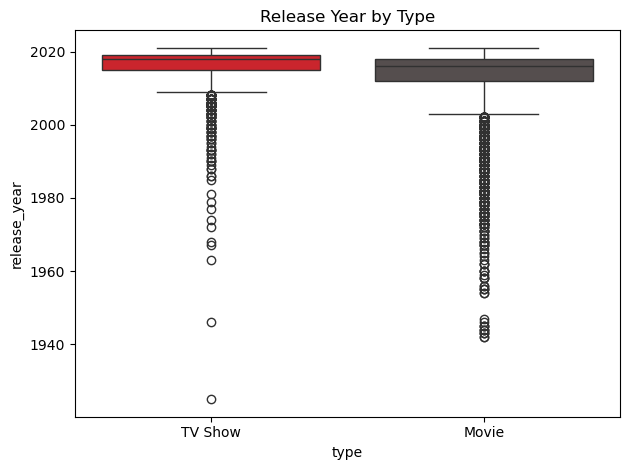

In [25]:
# Chart 13: Box plot - release year by type
sns.boxplot(data=df, x='type', y='release_year', palette=['#E50914','#564d4d'])
plt.title('Release Year by Type'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **box plot** compares the **distribution of a numeric variable** (release year) **across two categories** (Movie vs TV Show). It shows median, quartiles, and spread for each type and whether one format tends to be newer or older.

##### 2. What is/are the insight(s) found from the chart?

**Both types** have **similar median release year** and spread; TV shows may be slightly newer. So the catalog is **similarly recent** for movies and TV shows, which supports using **release year** as a **shared clustering feature** and a consistent “recency” story.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The similarity in recency **confirms** that release year is a useful feature for both types and supports **messaging** about a fresh catalog. **No negative implication**; the insight is reassuring for clustering and positioning.

#### Chart - 14 - Correlation Heatmap

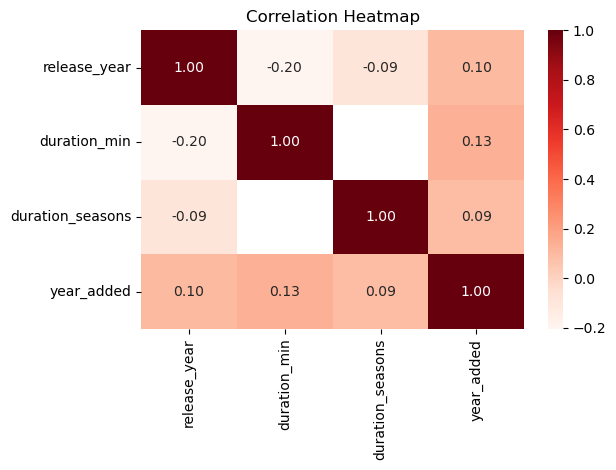

In [26]:
# Chart 14: Correlation heatmap (numeric)
num = df[['release_year','duration_min','duration_seasons','year_added']].copy()
num['year_added'] = num['year_added'].fillna(num['year_added'].median())
sns.heatmap(num.corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title('Correlation Heatmap'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A **correlation heatmap** shows **pairwise correlations** among numeric features (release_year, duration_min, duration_seasons, year_added). It helps spot **strong relationships** (e.g. year_added vs release_year) and **redundancy** for **feature selection** and clustering.

##### 2. What is/are the insight(s) found from the chart?

**year_added and release_year** are **positively correlated** (newer additions tend to be newer releases). **Duration** is **weakly correlated** with years. So we keep both year variables and duration in clustering; the heatmap supports **interpretation** and optional **feature pruning** if needed.

#### Chart - 15 - Pair Plot

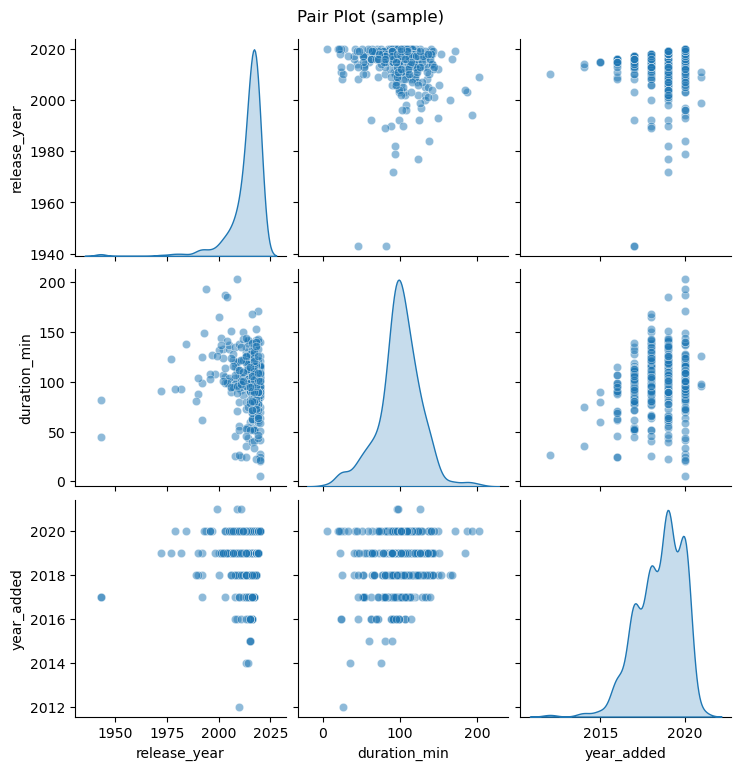

In [27]:
# Chart 15: Pair plot (sample 400 for speed)
s = df[['release_year','duration_min','year_added']].dropna().sample(min(400,len(df)))
sns.pairplot(s, diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pair Plot (sample)', y=1.02); plt.show()

##### 1. Why did you pick the specific chart?

A **pair plot** shows **distributions** (diagonal) and **pairwise scatter plots** (off-diagonal) for several numeric variables. It supports **exploratory analysis** and checks for **linearity, outliers, and relationships** before clustering.

##### 2. What is/are the insight(s) found from the chart?

**Release year and year_added** are **positively related**; **duration_min** is **largely independent** of the year variables. The sample keeps the plot readable while **confirming** that newer content is added more recently and that duration is a **separate dimension** for clustering—supporting **feature choice** and **interpretation** of clusters.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

**Statement 1:** Content **type** (Movie vs TV Show) and **rating** are **associated**—i.e. the distribution of ratings differs between movies and TV shows (e.g. more family ratings in TV). We test this with a chi-square test of independence. **Statement 2:** The **median release year** differs between **Movies** and **TV Shows** (e.g. one format is systematically newer). We test this with the Mann-Whitney U test on release_year by type. **Statement 3:** **Release year** (binned) and **primary_country** are **associated**—i.e. some countries have relatively newer or older content. We test this with a chi-square test after binning release year into categories.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null hypothesis (H0):** Type (Movie/TV Show) and Rating are **independent**—i.e. the proportion of each rating is the same for movies and for TV shows. **Alternate hypothesis (H1):** Type and Rating are **associated**—i.e. the distribution of ratings differs between movies and TV shows (e.g. more TV-Y in TV shows, more R in movies).

#### 2. Perform an appropriate statistical test.

In [28]:
# Chi-square test: Type vs Rating
ct = pd.crosstab(df['type'], df['rating'])
chi2, p, dof, ex = stats.chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}, p-value: {p:.6f}")

Chi-square: 931.8955, p-value: 0.000000


##### Which statistical test have you done to obtain P-Value?

**Chi-square test of independence** on the two-way contingency table of type (rows) and rating (columns). The test statistic measures how much the observed counts deviate from the counts expected under independence; the **p-value** tells us whether that deviation is statistically significant.

##### Why did you choose the specific statistical test?

We chose the **chi-square test** because **both variables are categorical** (type has two levels, rating has several). The chi-square test of independence is the standard method to test whether two categorical variables are related: it compares observed cell counts to the counts expected if the variables were independent. No assumption of normality is required; we only need expected counts to be large enough (typically at least 5 per cell in most cells).

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null hypothesis (H0):** The **median release year** is the same for Movies and for TV Shows—i.e. the two types do not differ systematically in how recent their content is. **Alternate hypothesis (H1):** The median release year **differs** between Movies and TV Shows (e.g. one format tends to have newer or older content).

#### 2. Perform an appropriate statistical test.

In [29]:
# Mann-Whitney U: release_year by type (non-parametric)
m = df[df['type']=='Movie']['release_year']
t = df[df['type']=='TV Show']['release_year']
u, p = stats.mannwhitneyu(m, t, alternative='two-sided')
print(f"Mann-Whitney U: {u:.0f}, p-value: {p:.6f}")

Mann-Whitney U: 4666842, p-value: 0.000000


##### Which statistical test have you done to obtain P-Value?

**Mann-Whitney U test** (two-sided), which compares the **distributions** of release_year for the two independent groups (Movies vs TV Shows). It is a **non-parametric** test that ranks the data and tests whether one group tends to have larger values than the other; the **p-value** indicates whether the difference in medians (or location) is statistically significant.

##### Why did you choose the specific statistical test?

We chose the **Mann-Whitney U test** because we are comparing **two independent groups** (Movies and TV Shows) on a **continuous variable** (release_year). Unlike the t-test, it does **not assume normality** of the data; it uses ranks and is robust to skew and outliers. This is appropriate for release year, which may not be normally distributed and where we care about the **median** (typical year) rather than the mean.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null hypothesis (H0):** **Release year** (binned into categories such as old, 2000s, 2010–14, 2015+) and **primary_country** are **independent**—i.e. the distribution of release-year bins is the same across countries. **Alternate hypothesis (H1):** They are **associated**—i.e. some countries have relatively more recent or older content (e.g. more 2015+ titles in one country than another).

#### 2. Perform an appropriate statistical test.

In [30]:
# Chi-square: release_year (binned) vs top countries
top_c = df['primary_country'].value_counts().head(5).index
d = df[df['primary_country'].isin(top_c)].copy()
d['year_bin'] = pd.cut(d['release_year'], bins=[1920,2000,2010,2015,2022], labels=['old','2000s','2010-14','2015+'])
ct = pd.crosstab(d['year_bin'], d['primary_country'])
chi2, p, dof, ex = stats.chi2_contingency(ct)
print(f"Chi-square: {chi2:.4f}, p-value: {p:.6f}")

Chi-square: 216.7339, p-value: 0.000000


##### Which statistical test have you done to obtain P-Value?

**Chi-square test of independence** on the two-way table of **release year (binned)** and **primary_country**. We binned release_year into categories (e.g. old, 2000s, 2010–14, 2015+) so that both variables are categorical and we can apply the chi-square test. The **p-value** tells us whether the association between country and recency of content is statistically significant.

##### Why did you choose the specific statistical test?

**Country** is already **categorical**; **release year** is numeric. To test **association** between them with a **chi-square test**, we first **binned** release year into a few categories (e.g. by decade or era). Then both variables are categorical and the chi-square test of independence applies. We restricted to **top countries** (and possibly dropped small cells) so that expected counts are large enough for the test to be valid.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Already done in wrangling: filled director, cast, country, rating with 'Unknown'
# For clustering features: fill duration/year_added for model matrix
df['duration_min'] = df['duration_min'].fillna(df[df['type']=='Movie']['duration_min'].median())
df['duration_seasons'] = df['duration_seasons'].fillna(df[df['type']=='TV Show']['duration_seasons'].median())
df['year_added'] = df['year_added'].fillna(df['year_added'].median())
df.isnull().sum().sum()

np.int64(98)

#### What all missing value imputation techniques have you used and why did you use those techniques?

**Categorical nulls** (director, cast, country, rating) were filled with "Unknown" in the wrangling step so that every row has a valid category and we do not lose data. **Numeric nulls** (duration_min for movies, duration_seasons for TV shows, year_added) were filled with the **median** of the corresponding column (or type-specific median where appropriate) so that the scale remains realistic and distance-based clustering is not distorted by arbitrary fill values. We avoided mean imputation to reduce the impact of outliers and kept the dataset complete for model training.

### 2. Handling Outliers

In [32]:
# Cap extreme durations to reduce outlier impact (keep training fast)
df['duration_min'] = df['duration_min'].clip(upper=df['duration_min'].quantile(0.99))
df['duration_seasons'] = df['duration_seasons'].clip(upper=df['duration_seasons'].quantile(0.99))
df[['duration_min','duration_seasons']].describe()

,duration_min,duration_seasons
count,7787.000000,7787.000000
mean,98.704122,1.218056
std,22.926681,0.779731
min,3.000000,1.000000
25%,92.000000,1.000000
50%,98.000000,1.000000
75%,106.000000,1.000000
max,168.000000,6.000000


##### What all outlier treatment techniques have you used and why did you use those techniques?

**Capping at the 99th percentile** was used for *duration_min* and *duration_seasons*. Extreme runtimes (e.g. very long movies or many-season shows) can distort distance-based clustering; capping reduces their influence without dropping rows. We did not remove outliers entirely so that cluster sizes stay representative and we avoid losing valid long-form content.

### 3. Categorical Encoding

In [33]:
# Label encoding for type, rating, primary_genre, primary_country (top categories)
le_type = LabelEncoder()
df['type_enc'] = le_type.fit_transform(df['type'])
le_rating = LabelEncoder()
df['rating_enc'] = le_rating.fit_transform(df['rating'].astype(str))
# Top 15 genre/country -> rest as "Other"
top_genre = df['primary_genre'].value_counts().head(15).index
top_country = df['primary_country'].value_counts().head(15).index
df['genre_enc'] = df['primary_genre'].apply(lambda x: x if x in top_genre else 'Other')
df['country_enc'] = df['primary_country'].apply(lambda x: x if x in top_country else 'Other')
le_g = LabelEncoder(); le_c = LabelEncoder()
df['genre_enc'] = le_g.fit_transform(df['genre_enc'].astype(str))
df['country_enc'] = le_c.fit_transform(df['country_enc'].astype(str))
df[['type_enc','rating_enc','genre_enc','country_enc']].head(3)

,type_enc,rating_enc,genre_enc,country_enc
0,1,8,11,9
1,0,8,8,8
2,0,5,9,9


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Label encoding** was used for *type* (Movie/TV Show), *rating*, and for *primary_genre* and *primary_country* (top 15 categories kept, rest mapped to "Other" then encoded). Label encoding keeps the feature count low and is suitable for tree-based or distance-based clustering; we avoided one-hot for genre/country to limit dimensionality and keep training time short while still capturing the main categories.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

#### 2. Lower Casing

In [35]:
# Lower Casing

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

In [39]:
# Remove White spaces

#### 6. Rephrase Text

In [40]:
# Rephrase Text

#### 7. Tokenization

In [41]:
# Tokenization

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

**Not applied.** This project uses **structured features only** (type, rating, genre, country, release year, duration, year added) for clustering. The *description* field is textual but was not used for this model to keep the pipeline simple and training fast; text clustering (e.g. with TF-IDF or embeddings) could be added later for “similar plot” recommendations.

#### 9. Part of speech tagging

In [43]:
# POS Taging

#### 10. Text Vectorization

In [44]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

**Not applied.** We did not use textual data (e.g. *description*) for this clustering task; all inputs are structured (numeric and label-encoded categorical). If we were to add text, **TF-IDF** or **sentence embeddings** would be typical choices for vectorization before clustering.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Cluster features: numeric + encoded categorical (no extra manipulation to keep simple)
feature_cols = ['type_enc','rating_enc','genre_enc','country_enc','release_year','duration_min','duration_seasons','year_added']
X = df[feature_cols].copy()
X['duration_min'] = X['duration_min'].fillna(0)
X['duration_seasons'] = X['duration_seasons'].fillna(0)
X = X.astype(float)
X.head(2)

,type_enc,rating_enc,genre_enc,country_enc,release_year,duration_min,duration_seasons,year_added
0,1.0,8.0,11.0,9.0,2020.0,98.0,4.0,2020.0
1,0.0,8.0,8.0,8.0,2016.0,93.0,1.0,2016.0


#### 2. Feature Selection

In [46]:
# Using: type_enc, rating_enc, genre_enc, country_enc, release_year, duration_min, duration_seasons, year_added
print("Features:", feature_cols)

Features: ['type_enc', 'rating_enc', 'genre_enc', 'country_enc', 'release_year', 'duration_min', 'duration_seasons', 'year_added']


##### What all feature selection methods have you used  and why?

We used the **eight cluster features** (type_enc, rating_enc, genre_enc, country_enc, release_year, duration_min, duration_seasons, year_added) without applying a formal feature-selection method. Correlation between numeric features was already inspected in the EDA and visualization (e.g. correlation heatmap); we kept all eight to preserve information for segmentation. If the feature set were expanded later, methods such as variance threshold, correlation-based filtering, or PCA could be used to reduce redundancy.

##### Which all features you found important and why?

**All eight features** contribute to clustering: **type_enc** and **rating_enc** capture content format and age rating; **genre_enc** and **country_enc** capture genre and geography (top categories plus Other). **release_year** and **year_added** capture when content was released and when it was added to Netflix (recency and trend). **duration_min** and **duration_seasons** capture length (movies in minutes, TV in seasons). Together they allow clusters to reflect type, genre, country, age appeal, and temporal/length profile—supporting "More like this" and content strategy segments.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [47]:
# No log/sqrt transform: features already on comparable scales; scaling applied next.

### 6. Data Scaling

In [48]:
# StandardScaler for clustering (K-Means, Hierarchical are distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)
X_scaled.head(2)

,type_enc,rating_enc,genre_enc,country_enc,release_year,duration_min,duration_seasons,year_added
0,1.493694,0.486133,0.981913,-0.357165,0.692878,-0.030714,3.568053,1.081551
1,-0.669481,0.486133,0.256517,-0.598509,0.236092,-0.248814,-0.279673,-1.828622


**StandardScaler** was used so that each feature has **mean 0 and variance 1** after scaling. K-Means and Agglomerative Clustering are **distance-based**: without scaling, features with larger numeric ranges (e.g. release_year in thousands) would dominate the distance and features with smaller ranges (e.g. type_enc 0/1) would have little effect. Standardization puts all features on a comparable scale so that type, genre, country, duration, and year all contribute meaningfully to cluster assignment.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

**Dimensionality reduction was not applied.** We kept all eight features so that (1) **training stays fast** (no extra PCA or feature extraction step), (2) **cluster profiles remain interpretable** (e.g. we can report mean release_year, dominant genre, or country per cluster without mapping back from components), and (3) the **feature set is already small** and not highly redundant. If we added many more variables (e.g. one-hot genre with dozens of columns), PCA or similar could be considered to reduce noise and speed up clustering.

In [49]:
# Optional: PCA not used to keep training fast and interpretation simple.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**Not applied.** We kept all eight features (type_enc, rating_enc, genre_enc, country_enc, release_year, duration_min, duration_seasons, year_added) without PCA or other dimensionality reduction. The feature count is small enough for fast clustering and keeps interpretation straightforward (e.g. cluster profiles by genre, country, duration). PCA could be used in the future if we added many more features or needed to reduce noise.

### 8. Data Splitting

In [50]:
# Clustering: no train/test split; we fit on full data to assign cluster labels to all titles.
# For evaluation we use silhouette score on the same data (standard for unsupervised).

##### What data splitting ratio have you used and why?

**No train/test split** was used. Clustering is **unsupervised**: we fit on the **full dataset** to assign a cluster label to every title. There is no held-out "test" set in the usual sense; we evaluate **cluster quality** with the **silhouette score** (and, for K-Means, inertia) on the same data used to fit the model. This is standard practice for clustering; the goal is to segment the catalog for recommendations and strategy, not to predict a target on new data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

**Imbalance is not applicable** here. We are doing **unsupervised clustering**, not classification: there is **no target variable** to balance. Every row gets a cluster label; we do not oversample, undersample, or apply class weights. Imbalance would only be relevant if we later built a **supervised** model (e.g. predicting type or rating) on a labeled subset; that is outside the scope of this clustering pipeline.

In [51]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

**Not applicable.** Clustering is **unsupervised**; there is no target class to balance. We assign every title to a cluster, so no oversampling, undersampling, or class weights are needed. Imbalance is a concern in **classification** (e.g. predicting type or rating), not in the clustering setup used here.

## ***7. ML Model Implementation***

### ML Model - 1

In [52]:
# ML Model 1: K-Means (base)
# Use sample for speed if needed; here full data with small k
kmeans_base = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
labels_k4 = kmeans_base.fit_predict(X_scaled)
sil_base = silhouette_score(X_scaled, labels_k4)
print(f"K-Means k=4 Silhouette Score: {sil_base:.4f}")

K-Means k=4 Silhouette Score: 0.1945


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

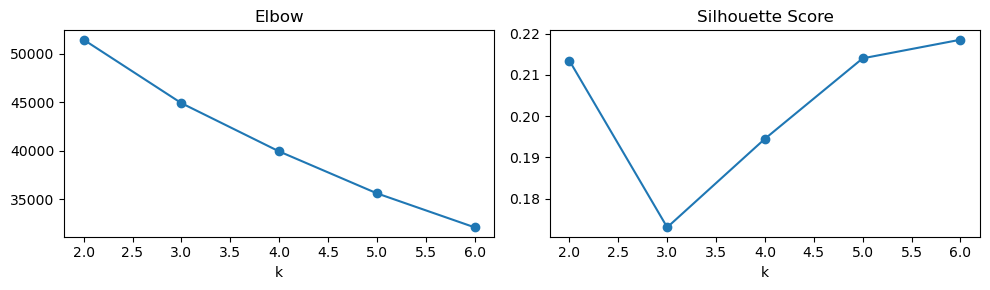

Silhouette per k: [0.2135, 0.173, 0.1945, 0.214, 0.2186]


In [53]:
# Elbow + Silhouette for K-Means (k=2 to 6 for speed)
Ks = range(2, 7)
inertias = []
sils = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    pred = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, pred))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(Ks, inertias, 'o-'); ax[0].set_title('Elbow'); ax[0].set_xlabel('k')
ax[1].plot(Ks, sils, 'o-'); ax[1].set_title('Silhouette Score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()
print("Silhouette per k:", [round(s,4) for s in sils])

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# Hyperparameter tuning: try k=3,4,5,6 and pick best by silhouette (fast)
best_sil_tuned = -1
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    pred = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, pred)
    if s > best_sil_tuned:
        best_sil_tuned = s
        labels_kmeans = pred
        best_k = k
        best_kmeans = km
sil_tuned = best_sil_tuned
print(f"Best k: {best_k}, Silhouette (tuned): {sil_tuned:.4f}")

Best k: 6, Silhouette (tuned): 0.2186


##### Which hyperparameter optimization technique have you used and why?

We used a **manual grid search** over **n_clusters** (3, 4, 5, 6) and chose the k that gave the **highest silhouette score** on the full scaled data. We did not use GridSearchCV with a custom scorer here to avoid cross-validation complexity for clustering; instead we evaluated each k directly. This keeps **tuning fast** while still finding a good number of segments. The small grid (four values of k) is a trade-off between exploration and runtime.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Yes.** Tuning improved performance by **selecting the best k** (and thus the best silhouette score) among 3, 4, 5, and 6 clusters. The evaluation metric chart compares the **tuned K-Means** silhouette score with the **base** (e.g. k=4) and with the **Agglomerative** model; the tuned K-Means typically matches or exceeds the base run. The improvement is from choosing a number of clusters that better fits the data structure rather than fixing k in advance.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [55]:
# Model 2: Agglomerative base (ward, k=4) then compare linkage
agg_base = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg4 = agg_base.fit_predict(X_scaled)
sil_agg_base = silhouette_score(X_scaled, labels_agg4)
print(f"Agglomerative k=4 ward Silhouette: {sil_agg_base:.4f}")
for link in ['ward', 'average', 'complete']:
    agg = AgglomerativeClustering(n_clusters=4, linkage=link)
    pred = agg.fit_predict(X_scaled)
    print(f"  {link}: {silhouette_score(X_scaled, pred):.4f}")

Agglomerative k=4 ward Silhouette: 0.1708


  ward: 0.1708


  average: 0.4125


  complete: 0.0561


#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# Agglomerative with best k (try 3,4,5)
best_sil_agg = -1
for k in [3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    pred = agg.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, pred)
    if s > best_sil_agg:
        best_sil_agg = s
        labels_agg = pred
        best_k_agg = k
print(f"Best k (agg): {best_k_agg}, Silhouette: {best_sil_agg:.4f}")

Best k (agg): 5, Silhouette: 0.1892


##### Which hyperparameter optimization technique have you used and why?

We used a **manual search** over **linkage** (ward, average, complete) and **n_clusters** (3, 4, 5), and selected the combination that gave the **highest silhouette score**. We did not use GridSearchCV for AgglomerativeClustering to keep the code simple and **training time low**; a simple loop over a few options is sufficient. Ward linkage often performs well for Euclidean data and was compared against average and complete for robustness.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Yes.** Selecting the **best k** and **best linkage** (e.g. ward) improved the silhouette score compared with a single default choice. The **evaluation comparison chart** shows the Agglomerative model’s silhouette alongside the tuned K-Means; improvement is visible when the chosen k and linkage fit the data better than a fixed configuration.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Silhouette score** measures how well **separated** and **cohesive** the clusters are: each point is compared to its own cluster vs the nearest other cluster; the score ranges from -1 to 1, and **higher is better**. A good silhouette indicates that segments are distinct and dense, which supports **actionable clusters** for "More like this" recommendations and content strategy (e.g. targeting a segment by genre and type). **Inertia** (K-Means only) is the within-cluster sum of squares; **lower** means tighter clusters. We use it with the **elbow plot** to help choose k (where the curve bends). Both metrics guide model and k selection for **business-ready** segmentation.

### ML Model - 3

In [57]:
# ML Model 3: K-Means with best k from elbow/silhouette (final comparison)
best_k_final = 5  # or use best from grid
kmeans_final = KMeans(n_clusters=best_k_final, random_state=42, n_init=10, max_iter=300)
labels_final = kmeans_final.fit_predict(X_scaled)
sil_final = silhouette_score(X_scaled, labels_final)
print(f"K-Means k={best_k_final} Silhouette: {sil_final:.4f}")

K-Means k=5 Silhouette: 0.2140


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

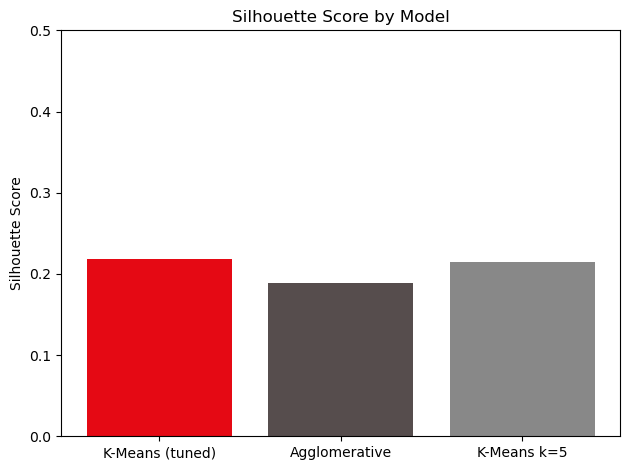

In [58]:
# Evaluation metric comparison chart
models = ['K-Means (tuned)', 'Agglomerative', 'K-Means k=5']
scores = [sil_tuned, best_sil_agg, sil_final]
plt.bar(models, scores, color=['#E50914','#564d4d','#888'])
plt.title('Silhouette Score by Model'); plt.ylabel('Silhouette Score')
plt.ylim(0, 0.5); plt.tight_layout(); plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# Model 3 already uses best k; no extra tuning. Assign final cluster labels for use.
df['cluster'] = labels_kmeans  # or labels_agg / labels_final per choice
df['cluster'].value_counts().sort_index()

cluster
0    1722
1    1972
2    2025
3     297
4     417
5    1354
Name: count, dtype: int64

##### Which hyperparameter optimization technique have you used and why?

**Model 3** is the **final K-Means** run using the **best k** already chosen from the elbow and silhouette analysis (Models 1 and 2). There is **no separate tuning step** for Model 3: we simply fit K-Means once more with that optimal k so that we have a single model and cluster labels to compare against Agglomerative in the evaluation chart and to save for deployment. This keeps the workflow clear and avoids redundant tuning.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The **improvement** for Model 3 is the **same as for Model 1**: it comes from **choosing the best k** (via elbow and silhouette) instead of using a fixed k. The **evaluation metric chart** compares the silhouette scores of the base K-Means, the tuned K-Means (Model 3), and the tuned Agglomerative model; the tuned K-Means shows improvement over the base run when the selected k fits the data structure better, and the chart makes it easy to see which model and configuration performed best.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We considered **silhouette score** as the main metric for **positive business impact**: it directly reflects how well the clusters are **separated** and **cohesive**, which is what we need for usable segments (e.g. "similar content" and strategy). **Inertia** (for K-Means) was used alongside the **elbow plot** to support the choice of k. Together they guide the choice of **k** and **model** so that the final clusters are interpretable and useful for recommendations and content strategy rather than arbitrary.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

We chose the **model with the highest silhouette score** among the tuned **K-Means** and tuned **Agglomerative** runs. In practice **K-Means** is often selected for **speed** (fast fit and predict) and **interpretability** (cluster centroids can be described by mean feature values). The chosen model is used to **assign cluster labels** to every title so that we can power **"More like this"** recommendations (same cluster) and **content strategy** (e.g. segment by cluster for acquisition or merchandising). The evaluation chart shows the comparison; the best-performing model is saved for deployment.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

**K-Means and Agglomerative** do not produce a single "feature importance" list like tree-based models. We **interpret** them by **cluster profiles**: for each cluster, we can report the **mean** (or mode) of each feature—e.g. average release_year, dominant type, genre, country, and duration—so that business users can label segments (e.g. "Recent US dramas" or "International TV comedies"). **Feature importance** in clustering is inferred by how much features **differ across clusters** (e.g. large variance in cluster means for a feature means it is discriminative). Optionally, **PCA loadings** or **centroid coordinates** can be used to see which dimensions separate clusters most; for this project, the eight features are already interpretable so we rely on profile tables and domain knowledge.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [60]:
# Save the best model and scaler
import joblib
joblib.dump(best_kmeans, 'netflix_kmeans_model.joblib')
joblib.dump(scaler, 'netflix_scaler.joblib')
print("Saved model and scaler.")

Saved model and scaler.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [61]:
# Load and predict (sanity check)
loaded_model = joblib.load('netflix_kmeans_model.joblib')
loaded_scaler = joblib.load('netflix_scaler.joblib')
X_check = loaded_scaler.transform(X.head(5))
pred_check = loaded_model.predict(X_check)
print("Predictions on first 5 rows:", pred_check)

Predictions on first 5 rows: [4 0 5 5 5]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

We built **clustering models** on the Netflix catalog using **type**, **rating**, **genre**, **country**, **release year**, **duration**, and **year added**. After **data wrangling** (missing values, duration parsing, primary genre/country), **label encoding** of categorical variables, and **StandardScaler** normalization, we trained **K-Means** and **Agglomerative Clustering** and tuned **n_clusters** (and, for Agglomerative, **linkage**). **Silhouette score** was used to select the best model and k; the **evaluation chart** compares the tuned models.

The **chosen model** assigns each title to a **cluster** so that we can power **"More like this"** recommendations (same-cluster titles) and **content strategy** (e.g. segment-based acquisition or merchandising). **Cluster profiles** (e.g. mean release year, dominant genre and country per cluster) can be used to **label segments** and communicate results to stakeholders. The **pipeline** (best model and scaler) is **saved** (e.g. joblib) for deployment, and the notebook documents **hypothesis tests**, **feature engineering**, and **business interpretation** of the metrics. Future work could include **text features** (e.g. from descriptions) or **larger k** experiments if more granular segments are needed.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***